In [1]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [2]:
# python standard library imports
from typing import Self, Any
from pathlib import Path

In [3]:
from keras.utils import image_dataset_from_directory

In [4]:
# augmentation operations
from keras.layers import Rescaling, RandAugment

In [5]:
from matplotlib.image import imread

In [6]:
from src.utils import show_image

In [7]:
# model building
from keras import Model
from keras.applications import VGG16
from keras.layers import Flatten, Dense

In [8]:
# model training imports
from keras.optimizers import SGD
from keras.losses import CategoricalCrossentropy
from keras.metrics import CategoricalAccuracy, AUC, F1Score
from keras.callbacks import ModelCheckpoint, CSVLogger, LearningRateScheduler

In [9]:
from src.utils import exp_decay_lr_scheduler

In [ ]:
# load data pointer from directory
# flowers dataset, 3 classes

In [11]:
root_dir_path = Path(".")
data_dir_path = root_dir_path / "flowers"

train_dir_path = data_dir_path / "train"
val_dir_path = data_dir_path / "val"
test_dir_path = data_dir_path / "test"

In [12]:
n_classes = 3
batch_size = 64
input_shape = (224, 224, 3)
image_size = (224, 224)
value_range = (0.0, 1.0)

In [13]:
train_ds = image_dataset_from_directory(
    train_dir_path,
    label_mode="categorical",
    batch_size=batch_size,
    image_size=image_size,
    interpolation="bilinear",
    verbose=False
)

In [14]:
val_ds = image_dataset_from_directory(
    val_dir_path,
    label_mode="categorical",
    batch_size=batch_size,
    image_size=image_size,
    interpolation="bilinear",
    shuffle=False,
    verbose=False
)

In [15]:
test_ds = image_dataset_from_directory(
    test_dir_path,
    label_mode="categorical",
    batch_size=batch_size,
    image_size=image_size,
    interpolation="bilinear",
    shuffle=False,
    verbose=False
)

In [16]:
# pre-trained model (transfer learning), with some augmentation

In [17]:
class AugmentedVGG16(Model):
    """
    Pre-trained VG16 + RandAugment
    """

    def __init__(self: Self) -> None:
        """
        Initialization
        """

        super().__init__()

        self.n_classes = n_classes
        self.rescale_layer = Rescaling(scale=1 / 255.0)
        self.augmentation_layer = RandAugment(value_range=value_range)
        self.pre_trained_architecture = VGG16(include_top=False, classes=32)
        self.flatten_layer = Flatten()
        self.dense_layer = Dense(self.n_classes, activation="softmax")

    def call(self: Self, inputs: Any) -> Any:
        """
        Forward call
        """

        x = self.rescale_layer(inputs)
        x = self.augmentation_layer(x)
        x = self.pre_trained_architecture(x)
        x = self.flatten_layer(x)

        return self.dense_layer(x)

In [18]:
# how RandAugment affects the image inputs?

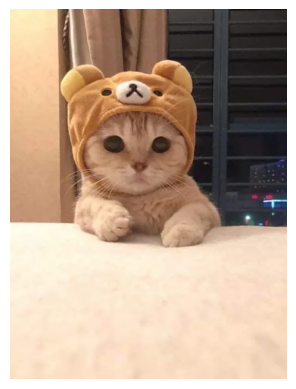

In [19]:
cute_cat_file_path = root_dir_path / "cute_cat.png"
cute_cat_example = imread(cute_cat_file_path)
show_image(cute_cat_example)

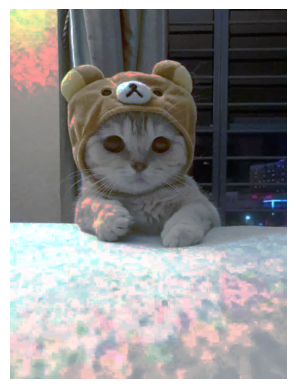

In [20]:
augmentation_layer = RandAugment(factor=0.1, value_range=value_range)
augmented_train_example = augmentation_layer(cute_cat_example).numpy()
show_image(augmented_train_example)

In [21]:
epochs = 4
model = AugmentedVGG16()
optimizer = SGD(learning_rate=0.001, name="optimizer")
loss = CategoricalCrossentropy(name="loss")

In [22]:
# metrics
categorical_accuracy = CategoricalAccuracy(name="accuracy")
auc = AUC(name="auc")
f1_score = F1Score(average="macro", name="f1_score")
metrics = [categorical_accuracy, auc, f1_score]

In [23]:
# callbacks
root_dir_path = Path(".")
checkpoint_file_path = root_dir_path / "checkpoint.keras"
metrics_file_path = root_dir_path / "metrics.csv"

checkpoint_callback = ModelCheckpoint(
    checkpoint_file_path,
    monitor="val_loss",
    verbose=0
)
metrics_callback = CSVLogger(metrics_file_path)
lr_scheduler_callback = LearningRateScheduler(exp_decay_lr_scheduler)

callbacks = [
    checkpoint_callback,
    metrics_callback,
    lr_scheduler_callback
]

In [24]:
model.compile(loss=loss, optimizer=optimizer, metrics=metrics)

In [25]:
# train the model, call to the method is somewhat diferent
_ = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks,
    verbose=2
)

Epoch 1/4
10/10 - 206s - 21s/step - accuracy: 0.3914 - auc: 0.5751 - f1_score: 0.3846 - loss: 1.1835 - val_accuracy: 0.3403 - val_auc: 0.5972 - val_f1_score: 0.1693 - val_loss: 3.1075 - learning_rate: 9.5000e-04
Epoch 2/4
10/10 - 201s - 20s/step - accuracy: 0.5931 - auc: 0.7469 - f1_score: 0.5761 - loss: 1.0396 - val_accuracy: 0.5707 - val_auc: 0.7456 - val_f1_score: 0.4445 - val_loss: 1.3187 - learning_rate: 9.0250e-04
Epoch 3/4
10/10 - 204s - 20s/step - accuracy: 0.7052 - auc: 0.8598 - f1_score: 0.6883 - loss: 0.7556 - val_accuracy: 0.7068 - val_auc: 0.8873 - val_f1_score: 0.7082 - val_loss: 0.6570 - learning_rate: 8.5737e-04
Epoch 4/4
10/10 - 203s - 20s/step - accuracy: 0.7362 - auc: 0.8966 - f1_score: 0.7313 - loss: 0.6395 - val_accuracy: 0.5183 - val_auc: 0.7862 - val_f1_score: 0.5134 - val_loss: 0.8507 - learning_rate: 8.1451e-04


In [26]:
# evaluate on the test ds
model.evaluate(
    test_ds,
    return_dict=True,
    verbose=0
)

{'accuracy': 0.5443037748336792,
 'auc': 0.8207594752311707,
 'f1_score': 0.5422033667564392,
 'loss': 0.7911661267280579}